In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [120]:
annual_value_adjusted = pd.read_csv("data/outputs/annual_ca_port",
                                    index_col =0, parse_dates = [1])
quarterly_value_adjusted = pd.read_csv('data/outputs/quarter_ca_port',
                                    index_col =0, parse_dates = [1])
band_value_adjusted = pd.read_csv("data/outputs/quarter_band_ca_port",
                                    index_col =0, parse_dates = [1])
asset_data = pd.read_csv("data/processed/daily_returns.csv",
                         parse_dates = [0])


In [121]:
annual_weights = pd.read_csv("data/outputs/annually_rebalanced_weights", 
                             index_col = 0, parse_dates = [1])
quarterly_weights = pd.read_csv("data/outputs/quarterly_rebalanced_weights", 
                                index_col = 0, parse_dates = [1])
band_weights = pd.read_csv("data/outputs/quarterly_rebalanced_byband_weights", 
                           index_col = 0, parse_dates = [1])
daily_returns = pd.read_csv("data/processed/daily_returns.csv", parse_dates = [0])

In [122]:
asset_data = daily_returns[daily_returns['Date'].isin(annual_value_adjusted['Date'])].reset_index().drop(columns=['index'])

## Return Contributions

In [123]:
def daily_asset_contributions(weights_df, asset_df):

    starting_weights = weights_df[weights_df['weight_type'] == 'starting']

    start_dates = weights_df.loc[weights_df['weight_type'] == 'starting', 'Date']

    end_dates = weights_df.loc[weights_df['weight_type'] == 'ending', 'Date']

    returns_list = []

    for row in range(len(start_dates)):

        start = start_dates.iloc[row]
        
        end = end_dates.iloc[row]

        period_data = asset_df[asset_df['Date'].between(start, end)]

        weights = starting_weights[starting_weights['Date'] == start].drop(columns = ['Date','weight_type'])

        for row in range(len(period_data)):

            returns_by_asset = weights.iloc[0] * period_data.iloc[row]

            returns_by_asset['Date'] = period_data['Date'].iloc[row]

            returns_list.append(returns_by_asset)

    return pd.DataFrame(returns_list).set_index('Date')


In [124]:

annual_portfolio_asset_contributions = daily_asset_contributions(annual_weights, asset_data)
quarterly_portfolio_asset_contributions = daily_asset_contributions(quarterly_weights, asset_data)
banded_portfolio_asset_contributions = daily_asset_contributions(band_weights, asset_data)

In [125]:
def asset_contributions_to_returns(portfolio_df, asset_contribution_df):
    weights_sums = []
    total_return = portfolio_df['portfolio_return'].sum()

    for col in asset_contribution_df.columns:
        name = asset_contribution_df[col].name
        col_sum = asset_contribution_df[col].sum()
        percent_cont = col_sum / total_return
        weights_sums.append({
            'asset' : name, 
            'total_return_contribution' : col_sum,
            'percent_contribution' : percent_cont
        })

    return pd.DataFrame(weights_sums).set_index('asset')


In [126]:
asset_contribution_table_annual = asset_contributions_to_returns(annual_value_adjusted, annual_portfolio_asset_contributions)
asset_contribution_table_quarterly = asset_contributions_to_returns(quarterly_value_adjusted, quarterly_portfolio_asset_contributions)
asset_contribution_table_band = asset_contributions_to_returns(band_value_adjusted, banded_portfolio_asset_contributions)

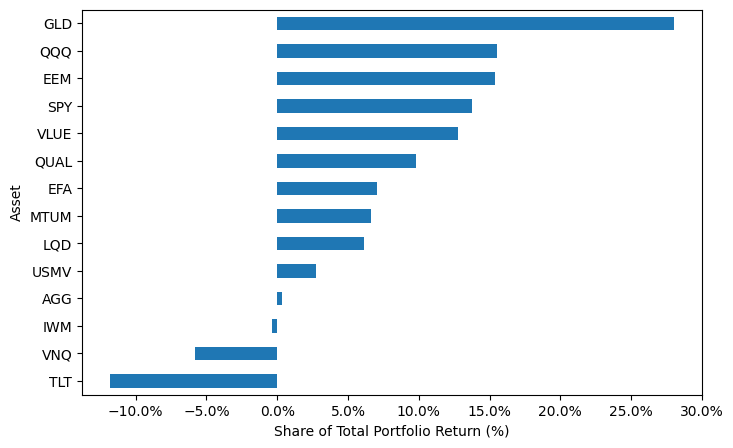

In [127]:
asset_contribution_table_band = asset_contribution_table_band.sort_values('percent_contribution', ascending= True)
fig, ax = plt.subplots(figsize=(8, 5))
asset_contribution_table_band.plot(kind = 'barh', y = 'percent_contribution', legend = False, ax = ax)
plt.xlabel('Share of Total Portfolio Return (%)')
plt.ylabel('Asset')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

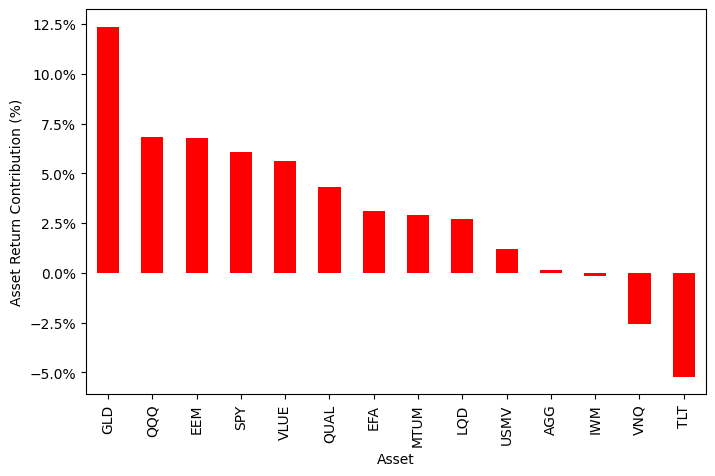

In [128]:
asset_contribution_table_band = asset_contribution_table_band.sort_values('total_return_contribution', ascending= False)
fig, ax = plt.subplots(figsize=(8, 5))
asset_contribution_table_band.plot(kind = 'bar', y = 'total_return_contribution', ax = ax, color = 'red', legend = False)
plt.xlabel('Asset')
plt.ylabel('Asset Return Contribution (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

In [129]:
portfolio_groups = {
    "Dom_Eq": ['SPY', 'QQQ', 'IWM'],
    "Intl_Eq": ['EFA', 'EEM'],
    "Fixed_Inc": ['AGG', 'TLT', 'LQD'],
    "Alt": ['GLD', 'VNQ'],
    "Factor": ['MTUM', 'VLUE', 'QUAL', 'USMV']
}
ticker_asset_class = {
    ticker: group
    for group, tickers in portfolio_groups.items()
    for ticker in tickers
}

In [130]:
asset_class_contributions_annual = annual_portfolio_asset_contributions.T.groupby(ticker_asset_class).sum().T # type: ignore
asset_class_contributions_quarterly = quarterly_portfolio_asset_contributions.T.groupby(ticker_asset_class).sum().T # type: ignore
asset_class_contributions_band = banded_portfolio_asset_contributions.T.groupby(ticker_asset_class).sum().T # type: ignore

In [131]:
def class_contributions_to_return(df, portfolio_df):
    total_return = portfolio_df['portfolio_return'].sum()

    asset_contribution_totals = []
    for col in df.columns:
        name = df[col].name
        col_sum = df[col].sum()
        percent_cont = col_sum / total_return
        asset_contribution_totals.append({
            'class' : name, 
            'total_return_contribution' : col_sum,
            'percent_contribution' : percent_cont
        })

    return pd.DataFrame(asset_contribution_totals).set_index('class')


In [132]:

class_contribution_table_annual = class_contributions_to_return(asset_class_contributions_annual, annual_value_adjusted)
class_contribtuion_table_quarterly = class_contributions_to_return(asset_class_contributions_quarterly, quarterly_value_adjusted)
class_contribtuion_table_band = class_contributions_to_return(asset_class_contributions_band, band_value_adjusted)

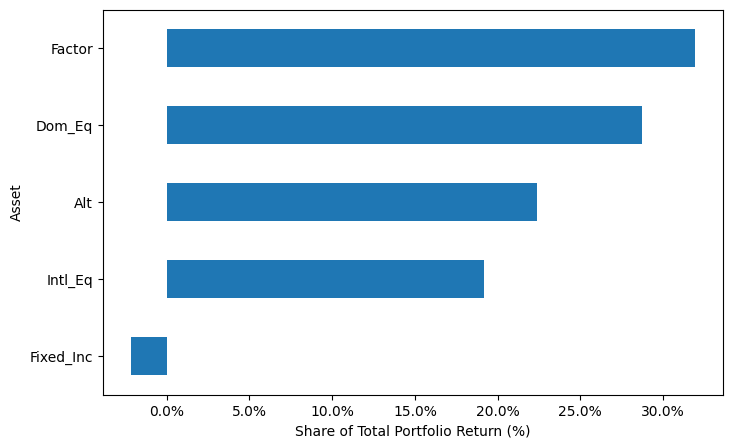

In [133]:
class_contribtuion_table_quarterly = class_contribtuion_table_quarterly.sort_values('percent_contribution', ascending= True)
fig, ax = plt.subplots(figsize=(8, 5))
class_contribtuion_table_quarterly.plot(kind = 'barh', y = 'percent_contribution', legend = False, ax = ax)
plt.xlabel('Share of Total Portfolio Return (%)')
plt.ylabel('Asset')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

## Risk Contributions

In [155]:
risk_data = asset_data.copy()
risk_data = asset_data.copy()
value_vars = risk_data.columns.drop('Date')

long_asset_data = risk_data.melt(
    id_vars='Date',
    value_vars=value_vars,
    var_name='asset',
    value_name='return'
)

long_asset_data['year'] = long_asset_data['Date'].dt.year

annual_asset_volatility = (
    long_asset_data
    .groupby(['year', 'asset'], as_index=False)
    .agg(
        annual_vol=('return', lambda x: x.std() * np.sqrt(252))
    )
)

In [172]:
asset_copy = asset_data.copy()
asset_copy = asset_copy.set_index('Date').T.groupby(ticker_asset_class).sum().T.reset_index() # type: ignore

value_vars2 = asset_copy.columns

long_class_data = asset_copy.melt(
    id_vars='Date',
    value_vars=value_vars2,
    var_name='asset',
    value_name='return'
)

long_class_data['year'] = long_class_data['Date'].dt.year

annual_class_volatility = (
    long_class_data
    .groupby(['year', 'asset'], as_index=False)
    .agg(
        annual_vol=('return', lambda x: x.std() * np.sqrt(252))
    )
)
annual_class_volatility

,year,asset,annual_vol
0,2022,Alt,0.326006
1,2022,Dom_Eq,0.826870
2,2022,Factor,0.881448
3,2022,Fixed_Inc,0.389854
4,2022,Intl_Eq,0.439749
5,2023,Alt,0.250178
6,2023,Dom_Eq,0.467524
7,2023,Factor,0.472947
8,2023,Fixed_Inc,0.348820
9,2023,Intl_Eq,0.273796


In [171]:
def annualized_portfolio_volatility(portfolio_df):

    portfolio_df['year'] = portfolio_df['Date'].dt.year

    volatility_df = (
    portfolio_df
    .groupby(['year'], as_index=False)
    .agg(
        annual_vol=('portfolio_return', lambda x: x.std() * np.sqrt(252))
        )
    )

    return volatility_df

In [192]:

avol_annual = annualized_portfolio_volatility(annual_value_adjusted)
avol_quarterly = annualized_portfolio_volatility(quarterly_value_adjusted)
avol_band = annualized_portfolio_volatility(band_value_adjusted)
avol_all = avol_annual.merge(
    avol_quarterly.merge(
        avol_band,
        on = 'year'
    ), on = 'year'
)
avol_all.columns = ['Year','Annually Rebalanced', 'Quarterly Rebalanced', 'Quarterly Reblanced w/ Band']
avol_all

,Year,Annually Rebalanced,Quarterly Rebalanced,Quarterly Reblanced w/ Band
0,2022,0.167323,0.159162,0.157932
1,2023,0.091324,0.088993,0.094849
2,2024,0.086896,0.090896,0.090248
3,2025,0.112741,0.109900,0.106188
4,2026,0.143457,0.154140,0.152202


In [190]:
class_vol_table = annual_class_volatility.pivot(index = 'year', columns=['asset'], values='annual_vol').reset_index()
class_vol_table.columns = ['Year', 'Alternative Assets','Domestic Equity', 'Factor Equity','Fixed Income','International Equity']
class_vol_table

,Year,Alternative Assets,Domestic Equity,Factor Equity,Fixed Income,International Equity
0,2022,0.326006,0.826870,0.881448,0.389854,0.439749
1,2023,0.250178,0.467524,0.472947,0.348820,0.273796
2,2024,0.253830,0.466632,0.479245,0.262005,0.266490
3,2025,0.274338,0.634601,0.665711,0.224637,0.324325
4,2026,0.386586,0.520224,0.659387,0.187594,0.467063


In [ ]:
def daily_asset_contributions(weights_df, asset_df):

    starting_weights = weights_df[weights_df['weight_type'] == 'starting']

    start_dates = weights_df.loc[weights_df['weight_type'] == 'starting', 'Date']

    end_dates = weights_df.loc[weights_df['weight_type'] == 'ending', 'Date']

    returns_list = []

    for row in range(len(start_dates)):

        start = start_dates.iloc[row]
        
        end = end_dates.iloc[row]

        period_data = asset_df[asset_df['Date'].between(start, end)]

        weights = starting_weights[starting_weights['Date'] == start].drop(columns = ['Date','weight_type'])

        for row in range(len(period_data)):

            returns_by_asset = weights.iloc[0] * period_data.iloc[row]

            returns_by_asset['Date'] = period_data['Date'].iloc[row]

            returns_list.append(returns_by_asset)

    return pd.DataFrame(returns_list).set_index('Date')


In [239]:
def portfolio_risk_metrics(weights_df, asset_df):

    starting_weights = weights_df[weights_df['weight_type'] == 'starting']

    start_dates = weights_df.loc[weights_df['weight_type'] == 'starting', 'Date']

    end_dates = weights_df.loc[weights_df['weight_type'] == 'ending', 'Date']

    mcr_list = []

    for row in range(len(start_dates)):

        start = start_dates.iloc[row]
        
        end = end_dates.iloc[row]

        period_data = asset_df[asset_df['Date'].between(start, end)]

        weights = starting_weights[starting_weights['Date'] == start].drop(columns = ['Date','weight_type'])

        covariance = period_data.set_index('Date').cov()

        period_std = np.sqrt(weights.iloc[0].T @ covariance @ weights.iloc[0])

        mcr = (covariance @ weights.iloc[0]) / period_std

        mcr_list.append({
            'Date': start,
            'MCR' : mcr
        })

    return pd.DataFrame(mcr_list)

portfolio_risk_metrics(annual_weights, asset_data)

,Date,MCR
0,2022-01-03,AGG 0.002975 EEM 0.010287 EFA 0.01...
1,2023-01-03,AGG 0.002552 EEM 0.007098 EFA 0.00...
2,2024-01-02,AGG 0.001586 EEM 0.006960 EFA 0.00...
3,2025-01-02,AGG 0.000714 EEM 0.009531 EFA 0.00...
4,2026-01-02,AGG 0.001457 EEM 0.017257 EFA 0.01...
